In [81]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set Theory

A **set** is an unordered collection of distinct elements. We start with a **universal set** $\Omega$, which contains every element under consideration. All other sets in the discussion are subsets of $\Omega$.

The **null set** (also called the **empty set**) $\varnothing = \{\}$ is the set with no elements at all. It is a subset of every set:
$$\varnothing \subseteq A \quad \text{for every set } A$$

In this section we work with:

$$\Omega = \{1,\, 2,\, 3,\, 4,\, 5,\, 6,\, 7,\, 8,\, 9,\, 10\}$$

and three subsets defined as:

| Set | Elements | Description |
|-----|----------|-------------|
| $\varnothing$ | $\{\}$ | Empty set — subset of every set |
| $A$ | $\{2, 4, 6, 8, 10\}$ | Even numbers in $\Omega$ |
| $B$ | $\{6, 7, 8, 9, 10\}$ | Numbers $\geq 6$ in $\Omega$ |
| $C$ | $\{2, 3, 5, 7\}$ | Primes in $\Omega$ |

We now implement and verify the core set operations on these sets.

> **`np.arange(start, stop)`** — Creates an integer array from `start` up to (but not including) `stop`.

In [82]:
# Universal set
Omega = np.arange(1, 11)  # {1,2,...,10}

# Null set
null_set = np.array([], dtype=int)

# Subsets
A = Omega[Omega % 2 == 0]  # even numbers
B = Omega[Omega >= 6]      # >= 6
C = np.array([2, 3, 5, 7]) # primes in Omega

print('Omega =', Omega)
print('null_set =', null_set)
print('A =', A)
print('B =', B)
print('C =', C)

Omega = [ 1  2  3  4  5  6  7  8  9 10]
null_set = []
A = [ 2  4  6  8 10]
B = [ 6  7  8  9 10]
C = [2 3 5 7]


> **`pd.Index(data)`** - Creates an immutable index-like collection that we can use to model set elements in pandas.

In [83]:
# Pandas equivalent
Omega_pd = pd.Index(range(1, 11), name='element')
null_set_pd = pd.Index([], dtype='int64')

A_pd = Omega_pd[Omega_pd % 2 == 0]
B_pd = Omega_pd[Omega_pd >= 6]
C_pd = pd.Index([2, 3, 5, 7], name='element')

print('Omega (pd.Index) =', Omega_pd.to_list())
print('null_set (pd.Index) =', null_set_pd.to_list())
print('A (pd.Index) =', A_pd.to_list())
print('B (pd.Index) =', B_pd.to_list())
print('C (pd.Index) =', C_pd.to_list())

Omega (pd.Index) = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
null_set (pd.Index) = []
A (pd.Index) = [2, 4, 6, 8, 10]
B (pd.Index) = [6, 7, 8, 9, 10]
C (pd.Index) = [2, 3, 5, 7]


### **NOTE :** We are working with pandas.Indexes not pandas.DataFrame or pandas.Series

In [84]:
print("A_pd type:", type(A_pd))
print("B_pd type:", type(B_pd))
print("C_pd type:", type(C_pd))

A_pd type: <class 'pandas.core.indexes.base.Index'>
B_pd type: <class 'pandas.core.indexes.base.Index'>
C_pd type: <class 'pandas.core.indexes.base.Index'>


***
### **How is pandas.Index different from pandas.DataFrame and pandas.Series?**


| Structure | Purpose | Shape | Example |
|-----------|---------|-------|---------|
| **`pd.Index`** | Represents a **single collection of labels/elements**—like a set. Optimized for set operations (`union`, `intersection`, `difference`). | 1D | `A_pd = pd.Index([2, 4, 6, 8, 10])` |
| **`pd.Series`** | Represents a **single labeled column of data** with a name and dtype. Each element is associated with an index label. | 1D (column vector) | `pd.Series([1, 0, 1], name='in_E_even')` |
| **`pd.DataFrame`** | Represents a **table with multiple columns and rows**. Each column is a `Series`; each row is indexed. | 2D | `pd.DataFrame({'outcome': [1,2,3], 'in_E': [1,0,1]})` |

**When to use each:**

- **`pd.Index`** — Use when you need to model **sets and perform set operations**. Index objects have direct methods for `union`, `intersection`, `difference`, and `equals` that mimic mathematical set operations. This is ideal for problem-like ours where you're working directly with elements and subsets.

- **`pd.Series`** — Use when you have a **1D labeled array of numeric or categorical data** and want to apply element-wise operations, aggregations (mean, sum, etc.), or filtering. In our DataFrame example, each column (`'in_E_even'`, `'in_E_lt4'`, `'in_E_prime'`) is a `Series` with binary values `0/1`.

- **`pd.DataFrame`** — Use when you need to organize **tabular data with multiple columns and rows**. A DataFrame is the most flexible structure for exploratory data analysis, filtering, grouping, and computing derived statistics. In our event-membership table, we built a DataFrame to show which outcomes belong to which events, then used `Series.mean()` to compute empirical probabilities.

**Key takeaway:** We used `pd.Index` for set operations (union, intersection, complement, partition) because it natively supports mathematical set semantics. We used `pd.DataFrame` for probability tables where we needed to associate outcomes with event indicators and compute aggregates. Choosing the right structure makes your code both clearer and more efficient.

## 1) Subset
$$
A \subseteq \Omega
$$
For sets `A` and `Omega`, this means every element of `A` appears in `Omega`.
In code, we verify this using element-wise membership using `np.isin` and `all()` over the result.

> **`np.isin(a, b)`** — Returns a boolean array of the same shape as `a`, with `True` where each element appears in `b`.

In [85]:
# Subset checks
print('A subset of Omega:', np.isin(A, Omega).all())
print('B subset of Omega:', np.isin(B, Omega).all())
print('C subset of Omega:', np.isin(C, Omega).all())
print('null_set subset of Omega:', np.isin(null_set, Omega).all())

A subset of Omega: True
B subset of Omega: True
C subset of Omega: True
null_set subset of Omega: True


> **`Index.isin(values)`** - Returns a boolean mask showing whether each index element is present in `values`.

In [86]:
# Pandas equivalent
print('A subset of Omega:', A_pd.isin(Omega_pd).all())
print('B subset of Omega:', B_pd.isin(Omega_pd).all())
print('C subset of Omega:', C_pd.isin(Omega_pd).all())
print('null_set subset of Omega:', null_set_pd.isin(Omega_pd).all())

A subset of Omega: True
B subset of Omega: True
C subset of Omega: True
null_set subset of Omega: True


## 2) Union
$$
A \cup B = \{x : x \in A \text{ or } x \in B\}
$$
`A union B` contains elements that are in `A`, in `B`, or in both.
For finite sets, NumPy's `union1d` returns the sorted unique union.

> **`np.union1d(a, b)`** — Returns the sorted unique values that appear in either `a` or `b`.

In [87]:
# Union operation
A_union_B = np.union1d(A, B)
print('A =', A)
print('B =', B)
print('A union B =', A_union_B)

A = [ 2  4  6  8 10]
B = [ 6  7  8  9 10]
A union B = [ 2  4  6  7  8  9 10]


> **`Index.union(other)`** - Returns the unique union of two indexes, similar to set union.

In [88]:
# Pandas equivalent
A_union_B_pd = A_pd.union(B_pd)
print('A (pd.Index) =', A_pd.to_list())
print('B (pd.Index) =', B_pd.to_list())
print('A union B (pd.Index) =', A_union_B_pd.to_list())

A (pd.Index) = [2, 4, 6, 8, 10]
B (pd.Index) = [6, 7, 8, 9, 10]
A union B (pd.Index) = [2, 4, 6, 7, 8, 9, 10]


## 3) Intersection
$$
A \cap B = \{x : x \in A \text{ and } x \in B\}
$$
`A intersection B` contains exactly the common elements of `A` and `B`.
This captures overlap between two events/sets.

Two special cases involving the null set:
- $A \cap \varnothing = \varnothing$ — intersecting anything with the empty set gives the empty set.
- When $A \cap B = \varnothing$, we say $A$ and $B$ are **disjoint** — they share no elements.

> **`np.intersect1d(a, b)`** — Returns the sorted unique values that appear in both `a` and `b`.

In [89]:
# Intersection operation
A_inter_B = np.intersect1d(A, B)
print('A =', A)
print('B =', B)
print('A intersection B =', A_inter_B)

# Null set identity: A ∩ ∅ = ∅
print('A ∩ null_set =', np.intersect1d(A, null_set))  # should be empty

A = [ 2  4  6  8 10]
B = [ 6  7  8  9 10]
A intersection B = [ 6  8 10]
A ∩ null_set = []


> **`Index.intersection(other)`** - Returns only the elements common to both indexes, similar to set intersection.

In [90]:
# Pandas equivalent
A_inter_B_pd = A_pd.intersection(B_pd)
print('A (pd.Index) =', A_pd.to_list())
print('B (pd.Index) =', B_pd.to_list())
print('A intersection B (pd.Index) =', A_inter_B_pd.to_list())

# Null set identity: A ∩ ∅ = ∅
print('A ∩ null_set (pd.Index) =', A_pd.intersection(null_set_pd).to_list())

A (pd.Index) = [2, 4, 6, 8, 10]
B (pd.Index) = [6, 7, 8, 9, 10]
A intersection B (pd.Index) = [6, 8, 10]
A ∩ null_set (pd.Index) = []


## 4) Difference
$$
A \setminus B = \{x : x \in A \text{ and } x \notin B\}
$$
`A \ B` keeps elements that are in `A` but removes any element that appears in `B`.
This is directional, so in general $A \setminus B \ne B \setminus A$.

> **`np.setdiff1d(a, b)`** — Returns the sorted unique values in `a` that are not present in `b`.

In [91]:
# Difference operation
A_minus_B = np.setdiff1d(A, B)
print('A =', A)
print('B =', B)
print('A \\ B =', A_minus_B)

A = [ 2  4  6  8 10]
B = [ 6  7  8  9 10]
A \ B = [2 4]


> **`Index.difference(other)`** - Returns elements in the first index that are not present in the second index.

In [92]:
# Pandas equivalent
A_minus_B_pd = A_pd.difference(B_pd)
print('A (pd.Index) =', A_pd.to_list())
print('B (pd.Index) =', B_pd.to_list())
print('A \\ B (pd.Index) =', A_minus_B_pd.to_list())

A (pd.Index) = [2, 4, 6, 8, 10]
B (pd.Index) = [6, 7, 8, 9, 10]
A \ B (pd.Index) = [2, 4]


## 5) Complement
$$
A^c = \{x \in \Omega : x \notin A\}
$$

The complement $A^c$ contains all elements of $\Omega$ that do **not** belong to $A$.

**Connection to set difference:** the complement is exactly the set difference between $\Omega$ and $A$:

$$
A^c = \Omega \setminus A
$$

This means we can compute the complement by taking every element in $\Omega$ and removing those that appear in $A$. In NumPy, `np.setdiff1d(Omega, A)` does precisely this.

**Null set properties of the complement:**
$$
A \cap A^c = \varnothing \qquad \text{(a set and its complement are always disjoint)}
$$
$$
A \cup A^c = \Omega \qquad \text{(together they cover the entire universal set)}
$$

In [93]:
# Complement operation
A_comp = np.setdiff1d(Omega, A)
print('Omega =', Omega)
print('A =', A)
print('A^c (in Omega) =', A_comp)

# Verify null set property: A ∩ A^c = ∅
print('A ∩ A^c =', np.intersect1d(A, A_comp), '← should be empty')
# Verify coverage: A ∪ A^c = Ω
print('A ∪ A^c = Omega:', np.array_equal(np.union1d(A, A_comp), Omega))

Omega = [ 1  2  3  4  5  6  7  8  9 10]
A = [ 2  4  6  8 10]
A^c (in Omega) = [1 3 5 7 9]
A ∩ A^c = [] ← should be empty
A ∪ A^c = Omega: True


> **`Index.equals(other)`** - Returns `True` when two indexes contain exactly the same elements in the same order.

In [94]:
# Pandas equivalent
A_comp_pd = Omega_pd.difference(A_pd)
print('Omega (pd.Index) =', Omega_pd.to_list())
print('A (pd.Index) =', A_pd.to_list())
print('A^c in Omega (pd.Index) =', A_comp_pd.to_list())

# Verify null set property: A ∩ A^c = ∅
print('A ∩ A^c (pd.Index) =', A_pd.intersection(A_comp_pd).to_list(), '← should be empty')
# Verify coverage: A ∪ A^c = Ω
print('A ∪ A^c = Omega:', A_pd.union(A_comp_pd).equals(Omega_pd))

Omega (pd.Index) = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
A (pd.Index) = [2, 4, 6, 8, 10]
A^c in Omega (pd.Index) = [1, 3, 5, 7, 9]
A ∩ A^c (pd.Index) = [] ← should be empty
A ∪ A^c = Omega: True


## 6) Partition

A **partition** of $\Omega$ is a way of splitting it into non-overlapping pieces that together cover everything.

Think of it like cutting a pizza: every slice is a separate piece (no overlap), and if you put all slices back together you get the whole pizza ($\Omega$).

Formally, subsets $P_1, P_2, \ldots, P_k$ form a partition of $\Omega$ if they satisfy **two conditions**:

**Condition 1 — No overlap (pairwise disjoint):**
$$P_i \cap P_j = \varnothing \quad \text{for all } i \ne j$$

**Condition 2 — Full coverage:**
$$P_1 \cup P_2 \cup \cdots \cup P_k = \Omega$$

In the code below, $\Omega = \{1,\ldots,10\}$ is split into:
- $P_1 = \{1,2,3\}$
- $P_2 = \{4,5,6\}$
- $P_3 = \{7,8,9,10\}$

We check both conditions programmatically.

> **`np.array_equal(a, b)`** — Returns `True` if two arrays have the same shape and identical elements, `False` otherwise.

In [95]:
# Disjointness and partition example
P1 = np.array([1, 2, 3])
P2 = np.array([4, 5, 6])
P3 = np.array([7, 8, 9, 10])

def disjoint(X, Y):
    '''
    Check if sets X and Y are disjoint by verifying that their intersection is empty.
    '''

    return len(np.intersect1d(X, Y)) == 0

pairwise_disjoint = disjoint(P1, P2) and disjoint(P1, P3) and disjoint(P2, P3)
union_all = np.union1d(np.union1d(P1, P2), P3)
is_partition = pairwise_disjoint and np.array_equal(union_all, Omega)

print('Pairwise disjoint:', pairwise_disjoint)
print('Union equals Omega:', np.array_equal(union_all, Omega))
print('Is partition of Omega:', is_partition)

Pairwise disjoint: True
Union equals Omega: True
Is partition of Omega: True


> **`Index.empty`** - Returns `True` when an index has no elements, which is useful for disjointness checks via empty intersections.

In [96]:
# Pandas equivalent
P1_pd = pd.Index([1, 2, 3], name='element')
P2_pd = pd.Index([4, 5, 6], name='element')
P3_pd = pd.Index([7, 8, 9, 10], name='element')

def disjoint_pd(X, Y):
    return X.intersection(Y).empty

pairwise_disjoint_pd = disjoint_pd(P1_pd, P2_pd) and disjoint_pd(P1_pd, P3_pd) and disjoint_pd(P2_pd, P3_pd)
union_all_pd = P1_pd.union(P2_pd).union(P3_pd)
is_partition_pd = pairwise_disjoint_pd and union_all_pd.equals(Omega_pd)

print('Pairwise disjoint (pd.Index):', pairwise_disjoint_pd)
print('Union equals Omega (pd.Index):', union_all_pd.equals(Omega_pd))
print('Is partition of Omega (pd.Index):', is_partition_pd)

Pairwise disjoint (pd.Index): True
Union equals Omega (pd.Index): True
Is partition of Omega (pd.Index): True


## 7) Set Laws

Set algebra obeys a set of named laws, just like arithmetic. We verify each one computationally using our sets $A$, $B$, and $C$.


#### **Commutative Law**
The order of operands does not matter for union or intersection.
$$
A \cup B = B \cup A, \qquad A \cap B = B \cap A
$$

In [97]:
# Commutative law
comm_union = np.array_equal(np.union1d(A, B), np.union1d(B, A))
comm_inter = np.array_equal(np.intersect1d(A, B), np.intersect1d(B, A))

print('Commutative union    (A∪B = B∪A):', comm_union)
print('Commutative intersect(A∩B = B∩A):', comm_inter)

Commutative union    (A∪B = B∪A): True
Commutative intersect(A∩B = B∩A): True


In [98]:
# Pandas equivalent
comm_union_pd = A_pd.union(B_pd).equals(B_pd.union(A_pd))
comm_inter_pd = A_pd.intersection(B_pd).equals(B_pd.intersection(A_pd))

print('Commutative union    (A∪B = B∪A):', comm_union_pd)
print('Commutative intersect(A∩B = B∩A):', comm_inter_pd)

Commutative union    (A∪B = B∪A): True
Commutative intersect(A∩B = B∩A): True


### **Associative Law**
Grouping does not matter when chaining the same operation.
$$
A \cup (B \cup C) = (A \cup B) \cup C
$$
$$
A \cap (B \cap C) = (A \cap B) \cap C
$$

In [99]:
# Associative law
assoc_union = np.array_equal(np.union1d(A, np.union1d(B, C)), np.union1d(np.union1d(A, B), C))
assoc_inter = np.array_equal(np.intersect1d(A, np.intersect1d(B, C)), np.intersect1d(np.intersect1d(A, B), C))

print('Associative union    (A∪(B∪C) = (A∪B)∪C):', assoc_union)
print('Associative intersect(A∩(B∩C) = (A∩B)∩C):', assoc_inter)

Associative union    (A∪(B∪C) = (A∪B)∪C): True
Associative intersect(A∩(B∩C) = (A∩B)∩C): True


In [100]:
# Pandas equivalent
assoc_union_pd = A_pd.union(B_pd.union(C_pd)).equals(A_pd.union(B_pd).union(C_pd))
assoc_inter_pd = A_pd.intersection(B_pd.intersection(C_pd)).equals(A_pd.intersection(B_pd).intersection(C_pd))

print('Associative union    (A∪(B∪C) = (A∪B)∪C):', assoc_union_pd)
print('Associative intersect(A∩(B∩C) = (A∩B)∩C):', assoc_inter_pd)

Associative union    (A∪(B∪C) = (A∪B)∪C): True
Associative intersect(A∩(B∩C) = (A∩B)∩C): True


### **Distributive Law**
Intersection distributes over union (and vice versa).
$$
A \cap (B \cup C) = (A \cap B) \cup (A \cap C)
$$

In [101]:
# Distributive law
left_dist  = np.intersect1d(A, np.union1d(B, C))
right_dist = np.union1d(np.intersect1d(A, B), np.intersect1d(A, C))
dist_ok = np.array_equal(left_dist, right_dist)

print('Left side  A∩(B∪C)       :', left_dist)
print('Right side (A∩B)∪(A∩C)   :', right_dist)
print('Distributive law holds  :', dist_ok)

Left side  A∩(B∪C)       : [ 2  6  8 10]
Right side (A∩B)∪(A∩C)   : [ 2  6  8 10]
Distributive law holds  : True


In [102]:
# Pandas equivalent
left_dist_pd = A_pd.intersection(B_pd.union(C_pd))
right_dist_pd = A_pd.intersection(B_pd).union(A_pd.intersection(C_pd))
dist_ok_pd = left_dist_pd.equals(right_dist_pd)

print('Left side  A∩(B∪C)       :', left_dist_pd.to_list())
print('Right side (A∩B)∪(A∩C)   :', right_dist_pd.to_list())
print('Distributive law holds   :', dist_ok_pd)

Left side  A∩(B∪C)       : [2, 6, 8, 10]
Right side (A∩B)∪(A∩C)   : [2, 6, 8, 10]
Distributive law holds   : True


### **De Morgan's Law**
The complement of a union is the intersection of the complements, and vice versa.
$$
(A \cup B)^c = A^c \cap B^c
$$
$$
(A \cap B)^c = A^c \cup B^c
$$

In [103]:
# De Morgan's law
left_dm  = np.setdiff1d(Omega, np.union1d(A, B))          # (A∪B)^c
right_dm = np.intersect1d(np.setdiff1d(Omega, A),
                          np.setdiff1d(Omega, B))        # A^c ∩ B^c
dm_union_ok = np.array_equal(left_dm, right_dm)

left_dm2  = np.setdiff1d(Omega, np.intersect1d(A, B))     # (A∩B)^c
right_dm2 = np.union1d(np.setdiff1d(Omega, A),
                        np.setdiff1d(Omega, B))           # A^c ∪ B^c
dm_inter_ok = np.array_equal(left_dm2, right_dm2)

print('(A∪B)^c = A^c ∩ B^c:', dm_union_ok)
print('(A∩B)^c = A^c ∪ B^c:', dm_inter_ok)

(A∪B)^c = A^c ∩ B^c: True
(A∩B)^c = A^c ∪ B^c: True


In [104]:
# Pandas equivalent
left_dm_pd = Omega_pd.difference(A_pd.union(B_pd))
right_dm_pd = Omega_pd.difference(A_pd).intersection(Omega_pd.difference(B_pd))
dm_union_ok_pd = left_dm_pd.equals(right_dm_pd)

left_dm2_pd = Omega_pd.difference(A_pd.intersection(B_pd))
right_dm2_pd = Omega_pd.difference(A_pd).union(Omega_pd.difference(B_pd))
dm_inter_ok_pd = left_dm2_pd.equals(right_dm2_pd)

print('(A∪B)^c = A^c ∩ B^c:', dm_union_ok_pd)
print('(A∩B)^c = A^c ∪ B^c:', dm_inter_ok_pd)

(A∪B)^c = A^c ∩ B^c: True
(A∩B)^c = A^c ∪ B^c: True


***
# Probability

In probability, we describe experiments using three parts:
$$
(\Omega, \mathcal{F}, P)
$$
- $\Omega$: sample space (all possible outcomes)
- $\mathcal{F}$: collection of events (subsets of $\Omega$)
- $P$: probability function that assigns a value between 0 and 1 to each event

For any event $E \in \mathcal{F}$:
$$
E \subseteq \Omega, \qquad 0 \le P(E) \le 1
$$

## Fair-Die Example
Let the sample space be:
$$
\Omega_{\text{die}} = \{1,2,3,4,5,6\}
$$

Events (subsets) used in this notebook:
- `E_even = {2,4,6}`: outcomes where the die is even
- `E_lt4 = {1,2,3}`: outcomes less than 4
- `E_prime = {2,3,5}`: outcomes that are prime

Reference events:
- $\varnothing$: impossible event, so $P(\varnothing)=0$
- $\Omega_{\text{die}}$: certain event, so $P(\Omega_{\text{die}})=1$

In the next code cell, we define these sets with NumPy arrays and verify they are subsets of $\Omega_{\text{die}}$.

In [105]:
Omega_die = np.arange(1, 7)
E_even = np.array([2, 4, 6])
E_lt4 = np.array([1, 2, 3])
E_prime = np.array([2, 3, 5])

events = {
    'E_even': E_even,
    'E_lt4': E_lt4,
    'E_prime': E_prime
}

print('Omega_die =', Omega_die)
for name, ev in events.items():
    print(f'{name} = {ev}, subset of Omega_die: {np.isin(ev, Omega_die).all()}')

Omega_die = [1 2 3 4 5 6]
E_even = [2 4 6], subset of Omega_die: True
E_lt4 = [1 2 3], subset of Omega_die: True
E_prime = [2 3 5], subset of Omega_die: True


In [106]:
# Build event-membership table with Pandas
df = pd.DataFrame({'outcome': Omega_die})
df['in_E_even'] = df['outcome'].isin(E_even).astype(int)
df['in_E_lt4'] = df['outcome'].isin(E_lt4).astype(int)
df['in_E_prime'] = df['outcome'].isin(E_prime).astype(int)

display(df)

print('P(E_even) from mean =', df['in_E_even'].mean())
print('P(E_lt4) from mean =', df['in_E_lt4'].mean())
print('P(E_prime) from mean =', df['in_E_prime'].mean())

,outcome,in_E_even,in_E_lt4,in_E_prime
0,1,0,1,0
1,2,1,1,1
2,3,0,1,1
3,4,1,0,0
4,5,0,0,1
5,6,1,0,0


P(E_even) from mean = 0.5
P(E_lt4) from mean = 0.5
P(E_prime) from mean = 0.5



## Probability Axioms

The three axioms below are the foundation of probability. Every valid probability model must satisfy all of them.

### **Axiom 1: Non-Negativity**
For any event $E$,
$$
P(E) \ge 0
$$

Why this matters:
- Probability measures chance, so it cannot be negative.
- A value like $-0.2$ would have no real interpretation as a chance.

Die example:
- $P(\{2,4,6\})=3/6=0.5 \ge 0$
- $P(\varnothing)=0 \ge 0$

### **Axiom 2: Normalization**
For the full sample space,
$$
P(\Omega)=1
$$

Why this matters:
- In one trial, **some** outcome in $\Omega$ must happen.
- So total probability across all possible outcomes is exactly 1 (100%).

Die example:
- $\Omega=\{1,2,3,4,5,6\}$
- $P(\Omega)=6/6=1$

### **Axiom 3: Additivity for Disjoint Events**
If two events do not overlap,
$$
A \cap B = \varnothing \quad \Rightarrow \quad P(A \cup B)=P(A)+P(B)
$$

Why this matters:
- If events are disjoint, they cannot happen together.
- So there is no double-counting when we add their probabilities.

Die example:
- Let $A=\{1,2\}$ and $B=\{3,4\}$, then $A\cap B=\varnothing$.
- $P(A)=2/6$, $P(B)=2/6$, and $P(A\cup B)=4/6=2/6+2/6$.

These axioms are the base rules. The later formulas (complement rule, union formula, monotonicity) are derived from them.


#### **Probability Function `P(E)`**

First We define the Probability Function `P(E)`

Here, **`E` means an event** (a subset of outcomes from the sample space).

For a fair die, each single outcome has probability:
$$
P(\omega)=\frac{1}{6}
$$

So for any event $E$, we compute its probability by **adding the probabilities of all outcomes inside $E$**:
$$
P(E)=\sum_{\omega\in E} P(\omega)
$$

Example:
- If $E=\{2,4,6\}$ (even outcomes), then
$$
P(E)=P(2)+P(4)+P(6)=\frac{1}{6}+\frac{1}{6}+\frac{1}{6}=\frac{3}{6}=\frac{1}{2}
$$

In the next code cell, `P(event_set)` does exactly this summation.

In [107]:
# Fair-die probability law
p_outcome = {int(x): 1/6 for x in Omega_die}

def P(event_set):
    # event_set is E: a subset of outcomes (list, set, or array)
    # We sum probability of each outcome w that belongs to E.
    return sum(p_outcome[int(x)] for x in set(event_set))

print('P(E_even) =', P(E_even))
print('P(E_lt4) =', P(E_lt4))
print('P(E_prime) =', P(E_prime))

P(E_even) = 0.5
P(E_lt4) = 0.5
P(E_prime) = 0.5


### Now we verify the Three Axioms
We now check:
- non-negativity,
- normalization,
- additivity for disjoint events.

Each printed `True` confirms that the fair-die model satisfies the corresponding axiom.

> **`np.isclose(a, b)`** — Returns `True` when `a` and `b` are approximately equal, which is useful for comparing decimal probability values.

In [108]:
# Axiom checks
listed_events = [E_even, E_lt4, E_prime]
non_negativity_ok = all(P(ev) >= 0 for ev in listed_events)
normalization_ok = np.isclose(P(Omega_die), 1.0)

D1 = np.array([1, 2])
D2 = np.array([3, 4])
disjoint = len(np.intersect1d(D1, D2)) == 0
additivity_ok = np.isclose(P(np.union1d(D1, D2)), P(D1) + P(D2))

print('Non-negativity holds:', non_negativity_ok)
print('Normalization holds:', normalization_ok)
print('D1 and D2 disjoint:', disjoint)
print('Additivity (for disjoint events) holds:', additivity_ok)

Non-negativity holds: True
Normalization holds: True
D1 and D2 disjoint: True
Additivity (for disjoint events) holds: True


### Now We Verify Standard Probability Properties
Using the same fair-die model, we verify these derived properties:

### 1) **Complement Rule**
$$
P(A^c)=1-P(A)
$$
If event $A$ does not happen, its complement $A^c$ happens.

### 2) **Union Formula (Inclusion-Exclusion for Two Events)**
$$
P(A\cup B)=P(A)+P(B)-P(A\cap B)
$$
We subtract $P(A\cap B)$ to avoid double-counting overlap.

### 3) **Union Bound**
$$
P(A\cup B)\le P(A)+P(B)
$$
The probability of "A or B" cannot exceed the sum of individual probabilities.

### 4) **Monotonicity**
$$
A\subseteq B \Rightarrow P(A)\le P(B)
$$
A smaller event cannot have higher probability than a larger event containing it.

In the next code cell, each property is checked numerically; `True` means the property holds for the chosen events.

In [109]:
# Verify standard probability properties using the fair-die model and events defined above.

# 1) Complement rule: P(A^c) = 1 - P(A)
E_even_c = np.setdiff1d(Omega_die, E_even)
complement_rule_ok = np.isclose(P(E_even_c), 1 - P(E_even))

# 2) Union formula: P(A U B) = P(A) + P(B) - P(A n B)
lhs_union_formula = P(np.union1d(E_even, E_lt4))
rhs_union_formula = P(E_even) + P(E_lt4) - P(np.intersect1d(E_even, E_lt4))
union_formula_ok = np.isclose(lhs_union_formula, rhs_union_formula)

# 3) Union bound: P(A U B) <= P(A) + P(B)
union_bound_ok = P(np.union1d(E_even, E_prime)) <= P(E_even) + P(E_prime)

# 4) Monotonicity: if A subseteq B, then P(A) <= P(B)
A_subset = np.array([2])
A_superset = np.array([2, 4, 6])
monotonicity_ok = P(A_subset) <= P(A_superset)

print('Complement rule:', complement_rule_ok)
print('Union formula:', union_formula_ok)
print('Union bound:', union_bound_ok)
print('Monotonicity:', monotonicity_ok)

Complement rule: True
Union formula: True
Union bound: True
Monotonicity: True


*** 
# Practice Problems

## Worked Example 1
A class has students numbered from 1 to 12.

**Data**
$$
\Omega = \{1,2,3,4,5,6,7,8,9,10,11,12\}
$$
- $M$ = students who play Music = $\{1,2,4,6,8,10\}$
- $S$ = students who play Sports = $\{2,3,5,6,9,10,12\}$
- $A$ = students who are in Art Club = $\{1,3,4,7,8,11\}$

**Question**
Find the students who:
1. are in **Music or Sports**
2. are in **both Music and Sports**
3. are in **Sports but not Art Club**
4. are in **none of the three groups**

**Mathematical Solution**
1. Music or Sports means union:
$$
M \cup S = \{1,2,3,4,5,6,8,9,10,12\}
$$

2. Both Music and Sports means intersection:
$$
M \cap S = \{2,6,10\}
$$

3. Sports but not Art Club means set difference:
$$
S \setminus A = \{2,5,6,9,10,12\}
$$

4. None of the three groups means outside the union of all three sets:
$$
(M \cup S \cup A)^c = \Omega \setminus (M \cup S \cup A)
$$
First,
$$
M \cup S \cup A = \{1,2,3,4,5,6,7,8,9,10,11,12\}
$$
So,
$$
\Omega \setminus (M \cup S \cup A) = \varnothing
$$

The next code cell solves the same questions step by step using NumPy.

In [110]:
# Universal set
Omega_practice = np.arange(1, 13)

# Group memberships
M = np.array([1, 2, 4, 6, 8, 10])
S = np.array([2, 3, 5, 6, 9, 10, 12])
A = np.array([1, 3, 4, 7, 8, 11])

# 1) Students in Music or Sports
music_or_sports = np.union1d(M, S)

# 2) Students in both Music and Sports
music_and_sports = np.intersect1d(M, S)

# 3) Students in Sports but not Art Club
sports_not_art = np.setdiff1d(S, A)

# 4) Students in none of the three groups
at_least_one_group = np.union1d(np.union1d(M, S), A)
none_of_three = np.setdiff1d(Omega_practice, at_least_one_group)

print('Music or Sports          =', music_or_sports)
print('Music and Sports         =', music_and_sports)
print('Sports but not Art Club  =', sports_not_art)
print('None of the three groups =', none_of_three)

Music or Sports          = [ 1  2  3  4  5  6  8  9 10 12]
Music and Sports         = [ 2  6 10]
Sports but not Art Club  = [ 2  5  6  9 10 12]
None of the three groups = []


## Practice Problem 1
Use the same student set from Worked Example 1.

**Data**
$$
\Omega = \{1,2,3,4,5,6,7,8,9,10,11,12\}
$$
- $M = \{1,2,4,6,8,10\}$
- $S = \{2,3,5,6,9,10,12\}$
- $A = \{1,3,4,7,8,11\}$

**Question for You**
Find:
1. students in **exactly one** of $M$ and $S$
Hint: $(M \setminus S) \cup (S \setminus M)$
2. students in **Music and Art but not Sports**
Hint: $(M \cap A) \setminus S$
3. students in **at least one** of the three groups
Hint: $M \cup S \cup A$

In [111]:
# solve here

## Practice Problem 2
A die is rolled once, with sample space
$$
\Omega = \{1,2,3,4,5,6\}
$$

Define events:
- $E$ = even outcomes = $\{2,4,6\}$
- $P$ = prime outcomes = $\{2,3,5\}$
- $L$ = outcomes less than 4 = $\{1,2,3\}$

**Question for You**
Find:
1. $E \cap P$
2. $E \cup L$
3. $L \setminus P$
4. $(E \cup P)^c$ with respect to $\Omega$

In [112]:
# solve here

## Practice Problem 3
A group has students numbered from 1 to 15.

**Data**
$$
\Omega = \{1,2,3,4,5,6,7,8,9,10,11,12,13,14,15\}
$$
- $P$ = students who study Physics = $\{1,2,5,7,9,10,13\}$
- $C$ = students who study Chemistry = $\{2,4,5,8,10,12,13,15\}$
- $B$ = students who study Biology = $\{1,3,4,8,9,11,14\}$

**Question for You**
Find the students who:
1. are in **Physics or Chemistry**
2. are in **both Physics and Chemistry**
3. are in **Chemistry but not Biology**
4. are in **none of the three groups**

Use the same steps as in the worked example.

In [113]:
# solve here

## Practice Problem 4
Use this to warm up before the harder problem.

**Data**
$$
\Omega = \{1,2,3,4,5,6,7,8,9,10\}
$$
- $A = \{1,2,4,6,8\}$
- $B = \{2,3,4,7,8,10\}$

**Question for You**
Find:
1. students in **both** sets
Hint: $A \cap B$
2. students in **exactly one** of the two sets
Hint: $(A \setminus B) \cup (B \setminus A)$
3. students in **neither** set
Hint: $\Omega \setminus (A \cup B)$

In [114]:
# solve here

## Practice Problem 5

**Data**
$$
\Omega = \{1,2,3,4,5,6,7,8,9,10,11,12\}
$$
- $P = \{1,2,4,6,8,10\}$
- $C = \{2,3,5,6,9,10,12\}$
- $B = \{1,3,4,7,8,11\}$

**Question for You**
Find:
1. students in **at least one** of $P,C,B$
Hint: $P \cup C \cup B$
2. students in **none** of $P,C,B$
Hint: $\Omega \setminus (P \cup C \cup B)$

In [115]:
# solve here

## Practice Problem 6
A survey is conducted on 18 students about the apps they use regularly.

**Data**
$$
\Omega = \{1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18\}
$$
- $W$ = students who use WhatsApp = $\{1,2,4,5,7,8,10,12,14,16\}$
- $I$ = students who use Instagram = $\{2,3,5,6,8,9,10,13,16,17\}$
- $Y$ = students who use YouTube = $\{1,3,4,6,8,10,11,14,15,18\}$

**Question for You**
Find the students who:
1. use **all three** apps
2. use **exactly one** of the three apps
3. use **at least two** of the three apps
4. use **WhatsApp and Instagram but not YouTube**
5. use **none** of the three apps

**Hint**
You need to combine multiple intersections, unions, and set differences carefully.

In [116]:
# solve here

## Worked Example 2
You are given `outcomes_1000`, a NumPy array containing outcomes from **1000 die throws** (each value is from 1 to 6).

**Task**
1. Compute the empirical probability of each outcome (1 through 6):
$$
\hat{P}(k)=\frac{\#\{\text{times outcome }k\text{ appears}\}}{1000},\quad k=1,\ldots,6
$$
2. Plot these six empirical probabilities in a bar chart.
3. Compare each bar with the fair-die probability $1/6$ and comment briefly on whether the die appears approximately fair.


Run the next code cell to compute frequencies, convert them to empirical probabilities, and visualize the result with a reference line at $1/6$.

Counts: {1: 128, 2: 160, 3: 176, 4: 178, 5: 184, 6: 174}
Empirical probabilities: {1: 0.128, 2: 0.16, 3: 0.176, 4: 0.178, 5: 0.184, 6: 0.174}
Sum of empirical probabilities = 1.0


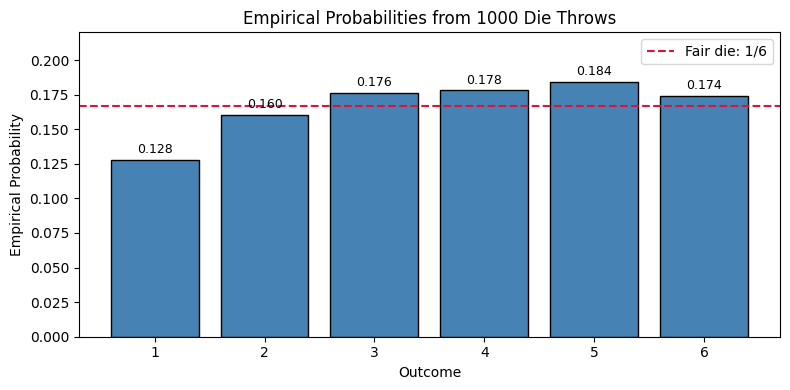

In [117]:
# Create a reproducible sample for demo.
outcomes_1000 = np.random.randint(1, 7, size=1000) # Recall that random.randint(a, b) generates integers in [a, b), so we use 1 to 7 to get 1..6.

# Count occurrences of 1..6 and compute empirical probabilities.
counts = np.bincount(outcomes_1000, minlength=7)[1:7] # np.bincount counts occurrences of integers starting from 0, so we use minlength=7 to ensure we have counts for 0..6, and then slice [1:7] to get counts for 1..6.
empirical_probs = counts / len(outcomes_1000)
faces = np.arange(1, 7)

print('Counts:', dict(zip(faces, counts)))
print('Empirical probabilities:', dict(zip(faces, np.round(empirical_probs, 4))))
print('Sum of empirical probabilities =', empirical_probs.sum())

# Plot empirical probabilities with fair-die reference (1/6).
plt.figure(figsize=(8, 4))
bars = plt.bar(faces, empirical_probs, color='steelblue', edgecolor='black')
plt.axhline(1/6, color='crimson', linestyle='--', label='Fair die: 1/6')
plt.xticks(faces)
plt.ylim(0, max(empirical_probs.max() + 0.03, 0.22))
plt.xlabel('Outcome')
plt.ylabel('Empirical Probability')
plt.title('Empirical Probabilities from 1000 Die Throws')

for bar, p in zip(bars, empirical_probs):
    plt.text(bar.get_x() + bar.get_width()/2, p + 0.005, f'{p:.3f}', ha='center', fontsize=9)

plt.legend()
plt.tight_layout()
plt.show()

## Practice Problem 7
You have to generate 2000 samples from a normal (Gaussian) distribution with mean $\mu=50$ and standard deviation $\sigma=8$.

**Task**
1. Generate the sample data.
2. Plot a histogram of the sample values (density scale).
3. Overlay the theoretical Gaussian PDF:
$$
N(\mu,\sigma^2)=\frac{1}{\sigma\sqrt{2\pi}}\exp\left(-\frac{(x-\mu)^2}{2\sigma^2}\right) 
$$
4. Mark the mean with a vertical line and add a legend/title.

Hint: If $Z \sim N(0,1)$ from `np.random.randn`, then $X = \mu + \sigma Z$ follows $N(\mu,\sigma^2)$.

In [118]:
# solve here

## Practice Problem 8
Build your own probability model on a finite sample space and compute event probabilities using a reusable function.

**Sample Space**
$$
\Omega = \{1,2,3,4,5\}
$$

**Probability Model**
$$
P(1)=0.10,\; P(2)=0.15,\; P(3)=0.20,\; P(4)=0.25,\; P(5)=0.30
$$

**Events to Evaluate**
- $E_1 = \{1,3,5\}$
- $E_2 = \{2,4\}$
- $E_3 = \{4,5\}$

**Task**
1. Write a function `P_custom(event_set, p_model)` that returns the probability of an event by summing probabilities of outcomes in that event.
2. Compute `P(E1)`, `P(E2)`, and `P(E3)`.
3. Verify normalization: `P(Ω) = 1`.
4. Verify non-negativity for the tested events.
5. Test one disjoint-additivity example:
$$
A \cap B = \varnothing \Rightarrow P(A \cup B) = P(A) + P(B)
$$

In [119]:
# Solve here
Omega_custom = np.array([1, 2, 3, 4, 5])
p_custom = {1: 0.10, 2: 0.15, 3: 0.20, 4: 0.25, 5: 0.30}

def P_custom(event_set, p_model):
    """
    Return probability of an event_set under the custom probability model p_model.

    event_set: iterable of outcomes (list, set, or numpy array)
    p_model: dict like {outcome: probability}
    """
    # Remove duplicates so repeated outcomes are not counted twice.
    unique_outcomes = set(event_set)

    total_probability = 0.0
    for outcome in unique_outcomes:
        if int(outcome) not in p_model:
            raise ValueError(f"Outcome {outcome} is not in the probability model.")
        total_probability += p_model[int(outcome)]

    return total_probability


# Continuing with the custom probability model and solve ahead